# Mortgage Reinsurance Probable Maximum Loss - Stochastic Loss Modelling Framework
### PML Engine 

This notebook is the engine behind simulating the mortgage reinsurance probable maximum losses. This simulation toolkit has an excel interface for inputs and outputs. Python performs all the heavy calculations inside this script helping to scale and make the process efficient.

The notebook asks for a file path for inputs and a folder path for output file. This is the folder where the final results would be stored. The user should first fill the "Inputs" file and provide necessary inputs for the modelling. Once the file is filled, it should be provided to this engine which would then generate the output and store it in the folder that the user selects. 

For this notebook, the Probable Maximum Loss (PML) is defined as the sum of all future calendar years' underwriting income or loss incurred on the treaty. 

The calculations coded in this engine can also be found in the excel file - **'PML Calculation Engine.xlsx'**. More information on this can be found in the **project documentation**.

Please note the following before running the script:
- Ensure 'pip install -U kaleido' is run on the command prompt or terminal for saving interactive heatmap of the United States
- PML output would be positive number, meaning that there is an underwriting loss, if they are negative it means there is an underwriting gain


In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import xlsxwriter
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage

In [3]:
#Ask for the file path that contains the user inputs 
file_path = input("Please enter the file path to the excel sheet that contains inputs:")

In [4]:
#Ask the user for the folder where the final output needs to be stored
folder_path = input("Enter the full folder path where you want to save the Output Excel file (no trailing slash):").strip()
output_file = folder_path + "\\Mortgage PML Results.xlsx"

In [5]:
#Import Loan Data from Excel file
loan_data = pd.read_excel(file_path, sheet_name="Loan Level Data Inputs", usecols='A:P', skiprows=3, header=0)

In [6]:
#Read Workbook
workbook = load_workbook(file_path, read_only=True)
assumptions_sheet = workbook['Assumptions']
treaty_features_sheet = workbook['Treaty Features']

In [7]:
#Import Data Frames from the Excel File

#Import Default Rates by FICO/LTV buckets
default_rates_by_fico_ltv_matrix = pd.read_excel(file_path, sheet_name="Assumptions", usecols='C:G', skiprows=6, nrows=5, header=None)
row_labels_matrix = ['< 80', '80-85', '85-90', '90-95', '> 95']
column_labels_matrix = ['< 650', '650-700', '700-750', '750-800', '> 800']
default_rates_by_fico_ltv = pd.DataFrame(default_rates_by_fico_ltv_matrix.values, index=row_labels_matrix, columns=column_labels_matrix)

#Import Loss Emergence Patterns
loss_emergence_patterns = pd.read_excel(file_path, sheet_name="Treaty Features", usecols='B:C', skiprows=24, nrows=16, header=0)

#Import Premiums Earnings Pattern
premium_earnings_pattern = pd.read_excel(file_path, sheet_name="Treaty Features", usecols='E:F', skiprows=24, nrows=16,header=0)


In [8]:
#Store Variables from worksheets

hpi_movement = assumptions_sheet['E14'].value
expense_loading = assumptions_sheet['E16'].value
recovery_lag = assumptions_sheet['E18'].value

insurer_name = treaty_features_sheet['C6'].value
treaty_code = treaty_features_sheet['C7'].value
treaty_start_date = treaty_features_sheet['C8'].value
treaty_end_date = treaty_features_sheet['C9'].value
basis_of_cover = treaty_features_sheet['C10'].value
quota_share_percentage = treaty_features_sheet['C11'].value
ceding_commission = treaty_features_sheet['C12'].value
reinsurance_margin = treaty_features_sheet['C13'].value
profit_commission = treaty_features_sheet['C14'].value
brokerage = treaty_features_sheet['C15'].value
federal_excise_taxes = treaty_features_sheet['C16'].value


In [9]:
#Write a function for assigning LTV group
def LTV_Group(LTV):
    if LTV < 80:
        return "< 80"
    elif 80<=LTV<=85:
        return "80-85"
    elif 85<LTV<=90:
        return "85-90"
    elif 90<LTV<=95:
        return "90-95"
    else:
        return "> 95"

#Write a function for assigning FICO group
def FICO_Group(FICO):
    if FICO < 650:
        return "< 650"
    elif 650<=FICO<=700:
        return "650-700"
    elif 700<FICO<=750:
        return "700-750"
    elif 750<FICO<=800:
        return "750-800"
    else:
        return "> 800"

#Write a function for fetching default rates
def fetch_default_rates(data_frame, LTV_Group, FICO_Group):
    return data_frame.loc[LTV_Group, FICO_Group]
    

#Write a function for getting loan level losses and prmeiums
def loss_prem_calc_df(data_frame, house_price_movement, exp_loading, recovery_lag):
    #Create a new dataframe of premium and loss amounts
    loss_prem_calc_df = pd.DataFrame({
        "Written Premium":loan_data['Premium Rate']*loan_data['Original Loan Amount']/100,
        "LTV Group":loan_data['Original LTV'].apply(LTV_Group), 
        "FICO Group":loan_data['FICO'].apply(FICO_Group),
        "Claim Severity (Option 1)":loan_data['Current Loan Amount']*loan_data['MI Coverage']*(1+exp_loading),
        "Claim Severity (Option 2)":(loan_data['Current Loan Amount']*(1+exp_loading))-(loan_data['Original Property Price']*(1+house_price_movement)),
                                     })
    #Add Default Rate Column
    loss_prem_calc_df['Default Rate'] = loss_prem_calc_df.apply(lambda row: fetch_default_rates(data_frame, row['LTV Group'], row['FICO Group']), axis=1)
    #Add Final Claim Severity Column
    loss_prem_calc_df['Final Claim Severity'] = loss_prem_calc_df.apply(lambda row: max(0,min(row['Claim Severity (Option 1)'], row['Claim Severity (Option 2)'])), axis=1)
    #Add Loss Amount Column
    loss_prem_calc_df['Loss Amount'] = loss_prem_calc_df['Final Claim Severity']*loss_prem_calc_df['Default Rate']

    return loss_prem_calc_df

loss_prem_df = loss_prem_calc_df(default_rates_by_fico_ltv, hpi_movement, expense_loading, recovery_lag)

In [10]:
#Write a function to generate PML table
def cashflows_table(data_frame, house_price_movement, exp_loading, recovery_lag,start_date, end_date, cession, cede_com, rm, profit_com, brok, fet):

    #Store loan level losses as a data frame
    loan_level_loss_prem_df = loss_prem_calc_df(data_frame, house_price_movement, exp_loading, recovery_lag)

    #Find total losses and premiums
    total_losses = loan_level_loss_prem_df['Loss Amount'].sum()
    total_premiums = loan_level_loss_prem_df['Written Premium'].sum()

    #Create a new data frame for PML table
    cashflow_table_df = pd.DataFrame({
        "Year":range(start_date.year, end_date.year+1)
                })
    #Add Earned Premiums
    cashflow_table_df['Earned Premium'] = cashflow_table_df.apply(lambda row: premium_earnings_pattern.loc[premium_earnings_pattern['Year.1']==1+row['Year']-start_date.year,'Incremental Loss Developed.1'].values[0]*total_premiums*cession, axis=1)
    #Add Incurred Losses
    cashflow_table_df['Incurred Losses'] = cashflow_table_df.apply(lambda row: loss_emergence_patterns.loc[loss_emergence_patterns['Year']==1+row['Year']-start_date.year, 'Incremental Loss Developed'].values[0]*total_losses*cession,axis=1)
    #Add Ceding Commission
    cashflow_table_df['Ceding Commission'] = cashflow_table_df['Earned Premium']*cede_com
    #Add Maximum Reinsurance Margin
    cashflow_table_df['Full Reinsurance Margin'] = cashflow_table_df['Earned Premium']*rm
    #Add Profit Commission
    cashflow_table_df['Profit Commission'] = np.where(cashflow_table_df['Earned Premium']-cashflow_table_df['Incurred Losses']-cashflow_table_df['Ceding Commission']>cashflow_table_df['Full Reinsurance Margin'],cashflow_table_df['Earned Premium']-cashflow_table_df['Incurred Losses']-cashflow_table_df['Ceding Commission']-cashflow_table_df['Full Reinsurance Margin'],0)
    #Add Brokerage
    cashflow_table_df['Brokerage'] = cashflow_table_df['Earned Premium']*brok
    #Add FET
    cashflow_table_df['Federal Excise Taxes'] = cashflow_table_df['Earned Premium']*fet
    #Add Underwriting Income and Losses
    cashflow_table_df['Underwriting Income/Loss']=cashflow_table_df['Earned Premium']-cashflow_table_df['Incurred Losses']-(cashflow_table_df['Ceding Commission']+cashflow_table_df['Profit Commission']+cashflow_table_df['Brokerage']+cashflow_table_df['Federal Excise Taxes'])
    #Add Loss Ratios
    cashflow_table_df['Loss Ratio'] = (cashflow_table_df['Incurred Losses'])/(cashflow_table_df['Earned Premium'])
    #Add Expense Ratios
    cashflow_table_df['Expense Ratio'] = (cashflow_table_df['Ceding Commission']+cashflow_table_df['Profit Commission']+cashflow_table_df['Brokerage']+cashflow_table_df['Federal Excise Taxes'])/(cashflow_table_df['Earned Premium'])
    #Add Combined Ratios
    cashflow_table_df['Combined Ratios'] = cashflow_table_df['Loss Ratio']+cashflow_table_df['Expense Ratio']    

    return cashflow_table_df

cashflow_table_df_export = cashflows_table(default_rates_by_fico_ltv, hpi_movement, expense_loading, recovery_lag, treaty_start_date, treaty_end_date, quota_share_percentage, ceding_commission, reinsurance_margin, profit_commission, brokerage, federal_excise_taxes)

In [11]:
#Write a function to find the final PML:
def PML(data_frame, house_price_movement, exp_loading, recovery_lag,start_date, end_date, cession, cede_com, rm, profit_com, brok, fet):

    #Store loan level losses as a data frame
    loan_level_loss_prem_df = loss_prem_calc_df(data_frame, house_price_movement, exp_loading, recovery_lag)

    #Store cashflows as a dataframe
    cashflows_table_df = cashflows_table(data_frame, house_price_movement, exp_loading, recovery_lag,start_date, end_date, cession, cede_com, rm, profit_com, brok, fet)

    #Find PML
    PML = cashflows_table_df['Underwriting Income/Loss'].sum()
    pd.set_option('display.float_format', '{:,.2f}'.format)
    PML = - PML.astype(float).round(2)
    
    return PML

loss_prem_df = loss_prem_calc_df(default_rates_by_fico_ltv, hpi_movement, expense_loading, recovery_lag)

In [12]:
#Simulate the PML 10000 times using different variables

#Create empty list
pml_results = []
for i in range(10):

    #Simulate Expense Loading factors
    simulated_exp_loading = np.random.uniform(0.03,0.20)

    #Simulate HPI index
    simulated_hpi_movement = np.random.normal(-0.05, 0.05)

    #Simulate defaults matrix
    simulated_defaults_matrix = np.array([
        [np.random.lognormal(-3.567, 0.3), np.random.lognormal(-3.791, 0.3), np.random.lognormal(-3.944, 0.4), np.random.lognormal(-4.710, 0.2),np.random.lognormal(-5.521, 0.2)],
        [np.random.lognormal(-3.282, 0.5), np.random.lognormal(-3.567, 0.2), np.random.lognormal(-3.754, 0.2), np.random.lognormal(-4.313, 0.15),np.random.lognormal(-5.115, 0.2)],
        [np.random.lognormal(-3.067, 0.6), np.random.lognormal(-3.282, 0.25), np.random.lognormal(-3.567, 0.2), np.random.lognormal(-4.313, 0.1),np.random.lognormal(-5.115, 0.2)],
        [np.random.lognormal(-2.494, 0.7), np.random.lognormal(-2.659, 0.3), np.random.lognormal(-2.867, 0.3), np.random.lognormal(-3.067, 0.1),np.random.lognormal(-3.389, 0.2)],
        [np.random.lognormal(-2.037, 0.8), np.random.lognormal(-2.659, 0.6), np.random.lognormal(-2.867, 0.6), np.random.lognormal(-3.067, 0.5),np.random.lognormal(-3.389, 0.5)],
    ])
    row_labels_matrix_sim = ['< 80', '80-85', '85-90', '90-95', '> 95']
    column_labels_matrix_sim = ['< 650', '650-700', '700-750', '750-800', '> 800']
    default_rates_by_fico_ltv_simulated = pd.DataFrame(simulated_defaults_matrix, index=row_labels_matrix_sim, columns=column_labels_matrix_sim)

    #Find PML
    pml = PML(default_rates_by_fico_ltv_simulated, simulated_hpi_movement, simulated_exp_loading, recovery_lag, treaty_start_date, treaty_end_date, quota_share_percentage, ceding_commission, reinsurance_margin, profit_commission, brokerage, federal_excise_taxes)

    #Append to list
    pml_results.append(pml)

In [13]:
#Final function for output

def PML_Simulated(data_frame, house_price_movement, exp_loading, recovery_lag,start_date, end_date, cession, cede_com, rm, profit_com, brok, fet):

    #Find PML at chosen functions
    PML_at_chosen_levels =  PML(default_rates_by_fico_ltv, hpi_movement, expense_loading, recovery_lag, treaty_start_date, treaty_end_date, quota_share_percentage, ceding_commission, reinsurance_margin, profit_commission, brokerage, federal_excise_taxes)

    #Find PML at different Confidence Intervals
    
    #Create empty list
    pml_results = []
    for i in range(1000):

        #Simulate Expense Loading factors
        simulated_exp_loading = np.random.uniform(0.03,0.20)

        #Simulate HPI index
        simulated_hpi_movement = np.random.normal(-0.15, 0.025)

        #Simulate defaults matrix
        simulated_defaults_matrix = np.array([
            [np.random.lognormal(-3.567, 0.3), np.random.lognormal(-3.791, 0.3), np.random.lognormal(-3.944, 0.4), np.random.lognormal(-4.710, 0.2),np.random.lognormal(-5.521, 0.2)],
            [np.random.lognormal(-3.282, 0.5), np.random.lognormal(-3.567, 0.2), np.random.lognormal(-3.754, 0.2), np.random.lognormal(-4.313, 0.15),np.random.lognormal(-5.115, 0.2)],
            [np.random.lognormal(-3.067, 0.6), np.random.lognormal(-3.282, 0.25), np.random.lognormal(-3.567, 0.2), np.random.lognormal(-4.313, 0.1),np.random.lognormal(-5.115, 0.2)],
            [np.random.lognormal(-2.494, 0.7), np.random.lognormal(-2.659, 0.3), np.random.lognormal(-2.867, 0.3), np.random.lognormal(-3.067, 0.1),np.random.lognormal(-3.389, 0.2)],
            [np.random.lognormal(-2.037, 0.8), np.random.lognormal(-2.659, 0.6), np.random.lognormal(-2.867, 0.6), np.random.lognormal(-3.067, 0.5),np.random.lognormal(-3.389, 0.5)],
        ])
        row_labels_matrix_sim = ['< 80', '80-85', '85-90', '90-95', '> 95']
        column_labels_matrix_sim = ['< 650', '650-700', '700-750', '750-800', '> 800']
        default_rates_by_fico_ltv_simulated = pd.DataFrame(simulated_defaults_matrix, index=row_labels_matrix_sim, columns=column_labels_matrix_sim)

        #Find PML
        pml = PML(default_rates_by_fico_ltv_simulated, simulated_hpi_movement, simulated_exp_loading, recovery_lag, treaty_start_date, treaty_end_date, quota_share_percentage, ceding_commission, reinsurance_margin, profit_commission, brokerage, federal_excise_taxes)

        #Append to list
        pml_results.append(pml)

    return pml_results


In [14]:
#Simulate PML list
pml_list=PML_Simulated(default_rates_by_fico_ltv, hpi_movement, expense_loading, recovery_lag, treaty_start_date, treaty_end_date, quota_share_percentage, ceding_commission, reinsurance_margin, profit_commission, brokerage, federal_excise_taxes)

#Create a dataframe
simulated_pml_df = pd.DataFrame({"Simulated PML Values": pml_list})

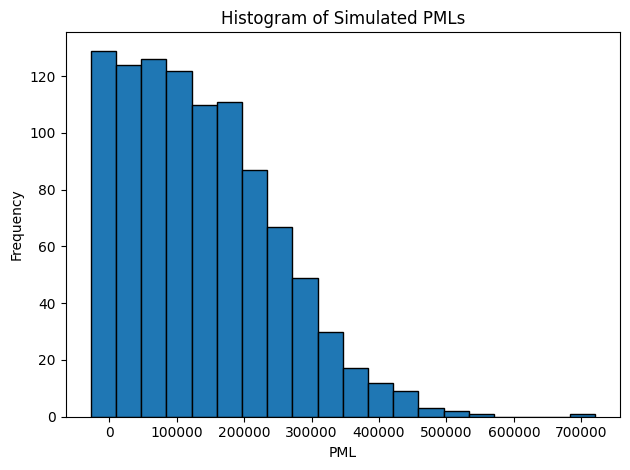

In [18]:
#Plot the histogram of PML amounts
plt.hist(pml_list, bins=20, edgecolor='black')
plt.title('Histogram of Simulated PMLs')
plt.xlabel('PML')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/pml_histogram.png')

The PML distribution is right-skewed with most simulated values clustering below $200,000. The long tail reflects scenarios where adverse HPI movements and high default rates coincide, driving extreme losses

In [16]:
#PML at different percentiles
PML_at_90_percentile = np.percentile(pml_list,90)
PML_at_95_percentile = np.percentile(pml_list,95)
PML_at_99_percentile = np.percentile(pml_list,99)
PML_at_chosen_parameters = PML(default_rates_by_fico_ltv, hpi_movement, expense_loading, recovery_lag, treaty_start_date, treaty_end_date, quota_share_percentage, ceding_commission, reinsurance_margin, profit_commission, brokerage, federal_excise_taxes)

#Create a dataframe
pml_results_df = pd.DataFrame({
    "Percentile": ["90%", "95%", "99%", "Chosen_Parameters"],
    "PML": [PML_at_90_percentile, PML_at_95_percentile, PML_at_99_percentile, PML_at_chosen_parameters] 
})


In [17]:
#Generate HeatMap of USA
states_losses_df = pd.concat([loan_data, loss_prem_df], axis=1)
state_losses = states_losses_df.groupby('State of Property')['Loss Amount'].sum().reset_index()
state_losses.columns = ['state_code', 'total_loss']
fig = px.choropleth(
    state_losses,
    locations='state_code',
    locationmode="USA-states",
    color='total_loss',
    scope="usa",
    color_continuous_scale="Reds",
    labels={'final_loss': 'Loss ($)'},
    title='Heatmap of Final Losses by State'
)
fig.write_image("images/state_loss_heatmap.png", width=1000, height=600)
fig.show()

Total losses are concentrated in Virginia, New Mexico, Texas, New York and Florida, reflecting a combination of portfolio size and higher-risk loan characteristics in those states. The geographic concentration highlights the importance of state-level diversification in managing mortgage reinsurance exposure.

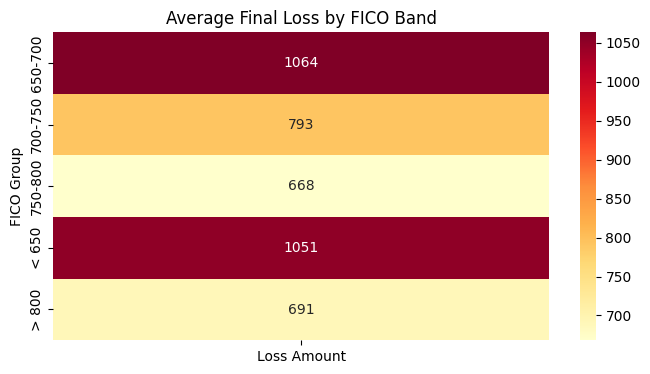

In [22]:
#Generate HeatMap for FICOs
fico_losses = loss_prem_df.groupby('FICO Group')['Loss Amount'].mean().reset_index()
fico_losses_pivot = fico_losses.set_index('FICO Group')
#FICO Map
plt.figure(figsize=(8, 4))
sns.heatmap(fico_losses_pivot, annot=True, cmap="YlOrRd", fmt=".0f")
plt.title("Average Final Loss by FICO Band")
plt.savefig("images/fico_heatmap.png", dpi=300)
plt.show()

Lower FICO bands drive higher average losses as expected, though the relationship is not strictly monotonic. The <650 band shows losses comparable to the 650-700 band, likely due to limited data in the extreme low-FICO segment.

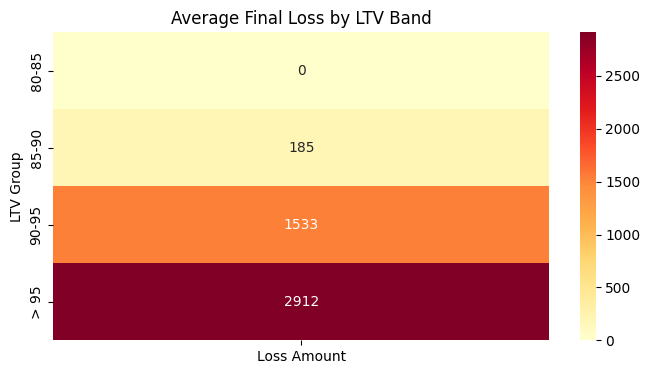

In [23]:
#LTV Heat Map
ltv_losses = loss_prem_df.groupby('LTV Group')['Loss Amount'].mean().reset_index()
ltv_losses_pivot = ltv_losses.set_index('LTV Group')
plt.figure(figsize=(8, 4))
sns.heatmap(ltv_losses_pivot, annot=True, cmap="YlOrRd", fmt=".0f")
plt.title("Average Final Loss by LTV Band")
plt.savefig("images/ltv_heatmap.png", dpi=300)
plt.show()

LTV is a stronger driver of losses than FICO, average loss jumps sharply above 90 LTV, with the >95 band producing losses nearly 16x the 85-90 band. This confirms LTV as the primary determinant of claim severity in this portfolio.

In [24]:
#Export to excel file
with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
    # Write DataFrames to their sheets
    states_losses_df.to_excel(writer, sheet_name="Loan Level Losses", index=False)
    cashflow_table_df_export.to_excel(writer, sheet_name="Cashflows Table", index=False)
    pml_results_df.to_excel(writer, sheet_name="PML Results", index=False)
    simulated_pml_df.to_excel(writer, sheet_name="PML Simulations", index=False)

    #Add histogram
    pml_sheet = writer.sheets["PML Simulations"]
    pml_sheet.insert_image("H2", "pml_histogram.png")

    #Add Heatmaps
    workbook  = writer.book
    worksheet = workbook.add_worksheet("Heatmaps")
    writer.sheets["Heatmaps"] = worksheet

    # Insert images
    worksheet.insert_image("B2", "images/state_loss_heatmap.png")     # US map
    worksheet.insert_image("S2", "images/fico_heatmap.png")  # FICO heatmap
    worksheet.insert_image("AF2", "images/ltv_heatmap.png")   # LTV heatmap

### End of Notebook